# Capstone — Content Refresh: Prioritizing Pages for Editorial Review

This notebook mirrors the deployed paper section by section, and generates the figures
and metrics JSON the paper embeds. Run top to bottom from a fresh clone.

In [1]:
import os, subprocess, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix,
)

REPO_PATH = "/content/flyrank-ml-internship"
DATA_PATH = f"{REPO_PATH}/data/raw/content_refresh_anonymized.csv"

if not os.path.exists(DATA_PATH):
    if os.path.exists(REPO_PATH):
        subprocess.run(["rm", "-rf", REPO_PATH], check=True)
    subprocess.run(
        ["git", "clone", "https://github.com/muhammadusmanshakir/flyrank-ml-internship.git", REPO_PATH],
        check=True
    )

os.makedirs(f"{REPO_PATH}/work/outputs", exist_ok=True)
os.makedirs(f"{REPO_PATH}/work/figures", exist_ok=True)

print("Environment ready.")

Environment ready.


## 1. Question

**Lane:** Content Refresh.

**Question:** which pages should an editorial team prioritize for review when deciding
what to refresh, out of a large and growing backlog?

**Unit of analysis:** one row = one content page.

**Action supported:** an editor opens the top of a ranked queue and reviews flagged
pages against a stated reason code; the model narrows the list, a person decides.

**Cost of a wrong call:** a false positive costs review time on a page that didn't need
it; a false negative delays review of a page that did. Neither is severe on its own,
which is why this stays a decision-support ranking rather than an automated action.

## 2. Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}  Columns: {len(df.columns)}")

FORBIDDEN = [
    "content_id", "client_id", "trend_direction", "trend_pct",
    "impressions_last_30d", "impressions_prev_30d",
    "clicks_last_30d", "clicks_prev_30d",
    "sessions_last_30d", "sessions_prev_30d",
]

FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days", "age_tier_order",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct",
]

assert not (set(FEATURES) & set(FORBIDDEN)), "Forbidden column found in feature set"
print(f"Feature set: {len(FEATURES)} columns, leakage check passed.")

Rows: 30,000  Columns: 44
Feature set: 23 columns, leakage check passed.


## 3. Methodology

Target: `decline_target` = 1 when a page's impressions in the most recent 30-day window
are lower than the prior 30-day window. Built only from the two window columns, neither
of which is a model feature. Baseline: `days_since_last_update >= 90 AND
impressions_90d >= 1000` → "Review content", else "Monitor". Model: Random Forest
(`n_estimators=200`, `random_state=42`). Validation: both a random 80/20 stratified
split and a `GroupShuffleSplit` grouped by `client_id`, compared directly.

In [3]:
df["decline_target"] = (df["impressions_last_30d"] < df["impressions_prev_30d"]).astype(int)

X = df[FEATURES].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))
y = df["decline_target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

baseline_pred = (
    (X_test["days_since_last_update"] >= 90) & (X_test["impressions_90d"] >= 1000)
).astype(int)

metrics_random = {
    "model_accuracy": accuracy_score(y_test, y_pred),
    "model_f1": f1_score(y_test, y_pred),
    "model_precision": precision_score(y_test, y_pred, zero_division=0),
    "model_recall": recall_score(y_test, y_pred, zero_division=0),
    "model_auc": roc_auc_score(y_test, y_prob),
    "baseline_accuracy": accuracy_score(y_test, baseline_pred),
    "baseline_f1": f1_score(y_test, baseline_pred, zero_division=0),
    "baseline_precision": precision_score(y_test, baseline_pred, zero_division=0),
    "baseline_recall": recall_score(y_test, baseline_pred, zero_division=0),
    "majority_class_rate": float(y_test.value_counts(normalize=True).max()),
}
print(json.dumps(metrics_random, indent=2))

{
  "model_accuracy": 0.7646666666666667,
  "model_f1": 0.8355079217148182,
  "model_precision": 0.7726783020900668,
  "model_recall": 0.9094598021810804,
  "model_auc": 0.795231045805746,
  "baseline_accuracy": 0.45416666666666666,
  "baseline_f1": 0.35161354187289645,
  "baseline_precision": 0.8014440433212996,
  "baseline_recall": 0.22520923154958153,
  "majority_class_rate": 0.6571666666666667
}


## 4. Results (vs. baseline)

Same target, same test rows, same metrics for both the baseline rule and the model.
Then the honest comparison: same model and features, only the split changes.

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))

X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

train_clients = set(df.iloc[train_idx]["client_id"])
test_clients = set(df.iloc[test_idx]["client_id"])
assert not (train_clients & test_clients), "Client overlap between train and test"

model_grouped = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_grouped.fit(X_train_g, y_train_g)
y_pred_g = model_grouped.predict(X_test_g)
y_prob_g = model_grouped.predict_proba(X_test_g)[:, 1]

metrics_grouped = {
    "grouped_accuracy": accuracy_score(y_test_g, y_pred_g),
    "grouped_f1": f1_score(y_test_g, y_pred_g),
    "grouped_precision": precision_score(y_test_g, y_pred_g, zero_division=0),
    "grouped_recall": recall_score(y_test_g, y_pred_g, zero_division=0),
    "grouped_auc": roc_auc_score(y_test_g, y_prob_g),
    "train_clients": len(train_clients),
    "test_clients": len(test_clients),
}
print(json.dumps(metrics_grouped, indent=2))

with open(f"{REPO_PATH}/work/outputs/capstone_metrics.json", "w") as f:
    json.dump({**metrics_random, **metrics_grouped}, f, indent=2)
print("Saved work/outputs/capstone_metrics.json")

{
  "grouped_accuracy": 0.6560116826220996,
  "grouped_f1": 0.7511737089201878,
  "grouped_precision": 0.6880240808428295,
  "grouped_recall": 0.8270871026104937,
  "grouped_auc": 0.6477774850864505,
  "train_clients": 25,
  "test_clients": 7
}
Saved work/outputs/capstone_metrics.json


impressions_90d          0.124989
avg_position             0.122049
days_with_impressions    0.118377
content_age_days         0.068764
char_count               0.061703
word_count               0.059885
ctr                      0.043575
pageviews_90d            0.041249
scroll_rate              0.036260
sessions_90d             0.035454
dtype: float64


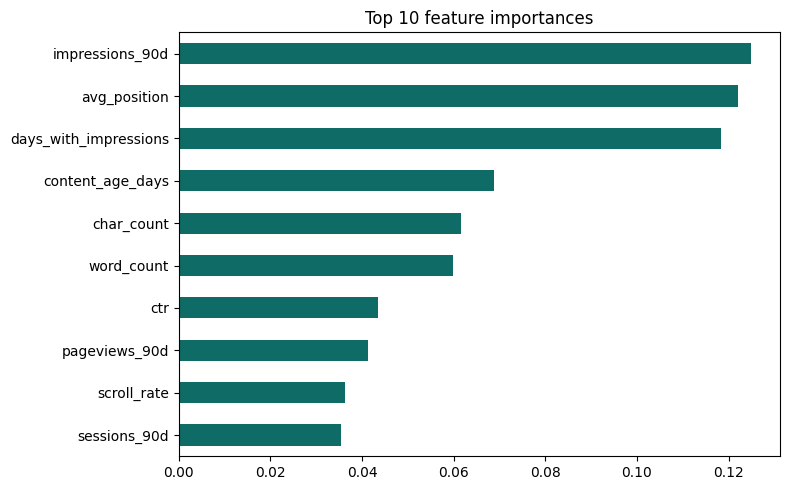

In [5]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

fig, ax = plt.subplots(figsize=(8, 5))
importances.head(10).sort_values().plot(kind="barh", ax=ax, color="#0F6B66")
ax.set_title("Top 10 feature importances")
plt.tight_layout()
plt.savefig(f"{REPO_PATH}/work/figures/feature_importance.png", dpi=150)
plt.show()

## 5. Limitations

`decline_target` is a rule-derived proxy for declining visibility, not a human-verified
judgment that a page needs a refresh. The client-grouped validation shows a substantial
generalization gap (ROC-AUC 0.795 → ~0.63 on unseen clients) — real signal, but modest.
The production scoring pass (Section 6) fits on all available rows, so its probability
values are not calibrated confidence and skew high; the ranking is the useful part, not
the raw number. No causal claims are made anywhere in this work.

## 6. Ranked recommendations

In [6]:
model_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_final.fit(X, y)

playbook_df = df.copy()
playbook_df["decline_probability"] = model_final.predict_proba(X)[:, 1]

def assign_reason(row):
    if row["days_since_last_update"] >= 91:
        return "DECAY_SIGNAL_HIGH"
    elif row["impressions_90d"] < 1000:
        return "LOW_TRAFFIC_SIGNAL"
    elif row["ctr"] < 0.05:
        return "LOW_CTR_SIGNAL"
    else:
        return "REVIEW_REQUIRED"

def assign_action(reason):
    return {
        "DECAY_SIGNAL_HIGH": "Review and refresh stale content",
        "LOW_TRAFFIC_SIGNAL": "Review search visibility and content coverage",
        "LOW_CTR_SIGNAL": "Review title and search-result presentation",
        "REVIEW_REQUIRED": "Perform manual content review",
    }[reason]

playbook_df["reason_code"] = playbook_df.apply(assign_reason, axis=1)
playbook_df["action"] = playbook_df["reason_code"].apply(assign_action)
playbook_df = playbook_df.sort_values("decline_probability", ascending=False).reset_index(drop=True)
playbook_df["rank"] = np.arange(1, len(playbook_df) + 1)

print(playbook_df["reason_code"].value_counts())

action_queue = playbook_df[
    ["rank", "content_id", "action", "reason_code", "decline_probability",
     "days_since_last_update", "impressions_90d", "ctr"]
].copy()
action_queue.to_csv(f"{REPO_PATH}/work/outputs/action_queue.csv", index=False)
print("Saved work/outputs/action_queue.csv")
action_queue.head(10)

reason_code
LOW_TRAFFIC_SIGNAL    12622
DECAY_SIGNAL_HIGH      9345
REVIEW_REQUIRED        6909
LOW_CTR_SIGNAL         1124
Name: count, dtype: int64
Saved work/outputs/action_queue.csv


,rank,content_id,action,reason_code,decline_probability,days_since_last_update,impressions_90d,ctr
0,1,content_a0a640a446ef,Perform manual content review,REVIEW_REQUIRED,1.0,20,15996,0.45
1,2,content_8854986f3027,Review and refresh stale content,DECAY_SIGNAL_HIGH,1.0,104,148,0.00
2,3,content_e8658537c97f,Perform manual content review,REVIEW_REQUIRED,1.0,20,8106,0.12
3,4,content_80856ce26978,Review and refresh stale content,DECAY_SIGNAL_HIGH,1.0,104,2243,0.00
4,5,content_071c40cf83c1,Review title and search-result presentation,LOW_CTR_SIGNAL,1.0,20,1389,0.00
5,6,content_19b2e2ca87ea,Perform manual content review,REVIEW_REQUIRED,1.0,20,13121,1.36
6,7,content_814313c94f86,Perform manual content review,REVIEW_REQUIRED,1.0,20,37506,0.53
7,8,content_b1dec12cc3db,Review and refresh stale content,DECAY_SIGNAL_HIGH,1.0,104,930,0.00
8,9,content_9ff654abaa21,Perform manual content review,REVIEW_REQUIRED,1.0,20,10620,0.65
9,10,content_a32f80dbc0d0,Perform manual content review,REVIEW_REQUIRED,1.0,20,1149,0.09


## 7. Artifacts the paper embeds

Figures and metrics saved above (`work/figures/feature_importance.png`,
`work/outputs/capstone_metrics.json`, `work/outputs/action_queue.csv`) are the sources
for every number and chart in the deployed paper — nothing in the paper should
contradict what this notebook produces on a fresh run.

In [7]:
required = ["model", "model_grouped", "metrics_random", "metrics_grouped", "action_queue"]
missing = [r for r in required if r not in globals()]
assert not missing, f"Missing: {missing}"
print("SELF-CHECK PASSED")

SELF-CHECK PASSED
